# IMPORTS

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.times.times import TimestampSanitizer

# LOAD DATA

## MDS versions

In [2]:
SOURCEDIR = r"../../50_REDDYPROC"
FILENAME = r"51.1_UstarThresholds_MDS-gapfilled_NEE-partitioned.csv"
FILEPATH = Path(SOURCEDIR) / FILENAME
mds = pd.read_csv(FILEPATH)

# Convert timestamp to datetime and change from end to middle
mds['TIMESTAMP_MIDDLE'] = pd.to_datetime(mds['TIMESTAMP_END'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce') - pd.Timedelta(minutes=15)
# Drop the timestamp end
mds.drop(columns='TIMESTAMP_END', inplace=True)
# Set the timestamp as index
mds.set_index('TIMESTAMP_MIDDLE', inplace=True)

# Rename for consistent naming with XGBoost versions
renaming_dict = {
    'NEE_U16_f': 'NEE_L3.3_CUT_16_QCF_footprint_gfMDS',
    'NEE_U50_f': 'NEE_L3.3_CUT_50_QCF_footprint_gfMDS',
    'NEE_U84_f': 'NEE_L3.3_CUT_84_QCF_footprint_gfMDS',
    'Reco_U16': 'RECO_NT_CUT_16_QCF_footprint_gfMDS',
    'Reco_U50': 'RECO_NT_CUT_50_QCF_footprint_gfMDS',
    'Reco_U84': 'RECO_NT_CUT_84_QCF_footprint_gfMDS',
    'GPP_U16_f': 'GPP_NT_CUT_16_QCF_footprint_gfMDS',
    'GPP_U50_f': 'GPP_NT_CUT_50_QCF_footprint_gfMDS',
    'GPP_U84_f': 'GPP_NT_CUT_84_QCF_footprint_gfMDS',
    'LE_f': 'LE_L3.2_QCF_footprint_gfMDS',
    'H_f': 'H_L3.2_QCF_footprint_gfMDS'
}
mds.rename(columns=renaming_dict, inplace=True)

# Drop thresholds
mds = mds[[c for c in renaming_dict.values()]].copy()

mds

,NEE_L3.3_CUT_16_QCF_footprint_gfMDS,NEE_L3.3_CUT_50_QCF_footprint_gfMDS,NEE_L3.3_CUT_84_QCF_footprint_gfMDS,RECO_NT_CUT_16_QCF_footprint_gfMDS,RECO_NT_CUT_50_QCF_footprint_gfMDS,RECO_NT_CUT_84_QCF_footprint_gfMDS,GPP_NT_CUT_16_QCF_footprint_gfMDS,GPP_NT_CUT_50_QCF_footprint_gfMDS,GPP_NT_CUT_84_QCF_footprint_gfMDS,LE_L3.2_QCF_footprint_gfMDS,H_L3.2_QCF_footprint_gfMDS
TIMESTAMP_MIDDLE,,,,,,,,,,,
2023-10-16 23:15:00,1.459812,1.461735,1.489906,1.567941,1.589532,1.646051,0.108129,0.127796,0.156144,5.547594,-10.692948
2023-10-16 23:45:00,1.450082,1.451357,1.478488,1.567941,1.589532,1.646051,0.117859,0.138175,0.167562,5.547594,-10.692948
2023-10-17 00:15:00,1.432370,1.432507,1.450670,1.510325,1.531747,1.587078,0.077955,0.099241,0.136408,5.556566,-9.246736
2023-10-17 00:45:00,1.424641,1.424261,1.441940,1.467896,1.489179,1.543615,0.043256,0.064918,0.101674,5.537643,-10.266117
2023-10-17 01:15:00,1.428483,1.428362,1.445870,1.486671,1.508017,1.562851,0.058188,0.079654,0.116980,5.556566,-9.246736
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 20:45:00,4.517046,4.611143,4.497522,4.180558,4.221801,4.275899,-0.336488,-0.389342,-0.221623,4.908718,-7.224344
2024-08-22 21:15:00,4.545872,4.603141,4.473330,4.016327,4.057722,4.112123,-0.529545,-0.545419,-0.361207,4.951884,-5.818081
2024-08-22 21:45:00,4.545872,4.603141,4.473330,4.002577,4.043981,4.098404,-0.543295,-0.559160,-0.374926,4.951884,-5.818081


## XGBoost versions

### Gap-filling results

In [3]:
gapfilled_df = load_parquet(Path("81.4.1_NEE_GF-XGBoost.parquet"))
gapfilled_df

Loaded .parquet file 81.4.1_NEE_GF-XGBoost.parquet (1.327 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,4.588344,4.588344,1,1.517483,1.404549,0.574454,1.517483,NaN,4.864410,4.133822,3.461763,3.898839,4.392054,5.065650,...,4.159542,5.479325,5.486156,5.842497,6.098002,5.997335,6.129688,6.274002,6.255286,5.207161,6.022611,5.630491,6.008531,4.158511,6.498959
2023-10-17 00:45:00,NaN,4.588344,4.588344,1,1.517978,1.404549,0.575760,1.517978,NaN,4.879979,4.137067,3.461763,3.898839,4.392054,5.065650,...,4.159542,5.479325,5.486156,5.842497,6.098002,5.997335,6.129688,6.274002,6.255286,5.207161,6.035096,5.630491,6.008531,4.158511,6.498959
2023-10-17 01:15:00,NaN,4.588344,4.588344,1,1.519817,1.404549,0.580591,1.519817,NaN,4.879979,4.137067,3.461763,3.888326,4.392054,5.127068,...,4.159542,5.479325,5.485127,5.842497,6.096806,5.997335,6.126984,6.274002,6.255286,5.207161,6.035096,5.630491,6.008531,4.158511,6.498959
2023-10-17 01:45:00,NaN,4.588344,4.588344,1,1.518928,1.404549,0.578261,1.518928,NaN,4.864410,4.137067,3.460015,3.888326,4.392054,5.127068,...,4.159542,5.479325,5.485127,5.842497,6.096806,5.997335,6.126984,6.274002,6.255286,5.207161,6.025538,5.630491,6.008531,4.158511,6.498959
2023-10-17 02:15:00,NaN,4.588344,4.588344,1,1.518481,1.404549,0.577084,1.518481,NaN,4.879979,4.137067,3.460015,3.888326,4.392054,5.111056,...,4.159542,5.451939,5.485127,5.842497,6.096806,6.004694,6.126984,6.242115,6.255286,5.207161,6.006851,5.627851,6.008531,4.137047,6.498959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,5.138743,5.138743,1,1.435312,1.404549,0.295574,1.435312,2.48319,5.315476,5.211159,5.539731,4.987913,4.851460,5.483131,...,5.912544,5.858134,5.469769,6.052450,5.357956,6.112972,5.646704,5.739465,5.410835,5.468698,6.196884,5.302804,5.925315,5.341684,5.892152
2024-08-22 22:15:00,NaN,5.188995,5.188995,1,1.448434,1.404549,0.353841,1.448434,1.96792,5.197551,5.501064,5.542127,4.730024,4.591958,5.402900,...,5.512691,5.682591,5.429472,5.690421,5.143887,5.473706,5.381833,5.229702,5.174486,5.104721,5.938176,4.821662,5.631627,5.233342,5.267423
2024-08-22 22:45:00,NaN,5.118667,5.118667,1,1.450231,1.404549,0.361125,1.450231,3.14515,5.107261,5.298507,5.287387,4.790768,4.617334,5.318227,...,5.412557,5.608435,5.319055,5.569763,5.072252,5.385814,5.277498,5.209002,5.122189,5.124244,5.820779,4.635873,5.484230,5.017087,5.143273


### Partitioning results

In [4]:
part_path = "81.5.1_NEE_XG-GAPF_PART_ReddyProc.csv"
part_df = pd.read_csv(part_path)
part_df = part_df.set_index("TIMESTAMP")
part_df.index.name = "TIMESTAMP_END"
part_df = TimestampSanitizer(data=part_df).get()
part_df

,Tair_orig,Tair_f,Tair_fqc,Tair_fall,Tair_fall_qc,Tair_fnum,Tair_fsd,Tair_fmeth,Tair_fwin,Rg_orig,Rg_f,Rg_fqc,Rg_fall,Rg_fall_qc,Rg_fnum,...,FP_GPP2000,FP_k,FP_beta,FP_alpha,FP_RRef,FP_E0,FP_k_sd,FP_beta_sd,FP_alpha_sd,FP_RRef_sd,FP_E0_sd,Reco_DT_QCF0,GPP_DT_QCF0,Reco_DT_QCF0_SD,GPP_DT_QCF0_SD
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,1.966667,1.966667,0,1.966667,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.069252,0.0,0.080790,0.0
2023-10-17 00:45:00,1.966667,1.966667,0,1.966667,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.069252,0.0,0.080790,0.0
2023-10-17 01:15:00,1.566667,1.566667,0,1.566667,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065129,0.0,0.076336,0.0
2023-10-17 01:45:00,1.266667,1.266667,0,1.266667,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.062156,0.0,0.073111,0.0
2023-10-17 02:15:00,1.400000,1.400000,0,1.400000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.063465,0.0,0.074532,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,15.870000,15.870000,0,15.870000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.083738,0.0,0.272792,0.0
2024-08-22 22:15:00,15.160000,15.160000,0,15.160000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.027941,0.0,0.267646,0.0
2024-08-22 22:45:00,15.100000,15.100000,0,15.100000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.023195,0.0,0.267233,0.0


# CLEAN PARTITIONING RESULTS

## Identify GPP and RECO columns

In [5]:
partcols = [c for c in part_df.columns if any(substring in c for substring in ["GPP", "Reco"])];
partcols = [c for c in partcols if not str(c).endswith("_fqc") and not str(c).endswith("_SD") and '_DT' not in c] 
partcols.remove("FP_GPP2000")
partcols

['Reco_QCF', 'GPP_QCF_f', 'Reco_QCF0', 'GPP_QCF0_f']

## Create subset with GPP and RECO columns

In [6]:
subset_partcols = part_df[partcols].copy()
subset_partcols

,Reco_QCF,GPP_QCF_f,Reco_QCF0,GPP_QCF0_f
TIMESTAMP_MIDDLE,,,,
2023-10-17 00:15:00,1.314534,-4.642565,1.314534,-4.642565
2023-10-17 00:45:00,1.314534,-4.642565,1.314534,-4.642565
2023-10-17 01:15:00,1.281012,-4.676087,1.281012,-4.676087
2023-10-17 01:45:00,1.256072,-4.701027,1.256072,-4.701027
2023-10-17 02:15:00,1.267135,-4.689964,1.267135,-4.689964
...,...,...,...,...
2024-08-22 21:45:00,4.614936,-1.174224,4.614936,-1.174224
2024-08-22 22:15:00,4.489070,-1.229992,4.489070,-1.229992
2024-08-22 22:45:00,4.478460,-1.028798,4.478460,-1.028798


## Rename partitioning variables

In [7]:
renaming_dict = {
    # Nighttime paritioning results for parcels A and B
    'GPP_QCF_f': 'GPP_NT_CUT_50_QCF_footprint_gfXGBoost', 
    'GPP_QCF0_f': 'GPP_NT_CUT_50_QCF0_footprint_gfXGBoost',
    'Reco_QCF': 'RECO_NT_CUT_50_QCF_footprint_gfXGBoost',
    'Reco_QCF0': 'RECO_NT_CUT_50_QCF0_footprint_gfXGBoost'
}

subset_partcols = subset_partcols.rename(columns=renaming_dict, inplace=False)
subset_partcols

,RECO_NT_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,RECO_NT_CUT_50_QCF0_footprint_gfXGBoost,GPP_NT_CUT_50_QCF0_footprint_gfXGBoost
TIMESTAMP_MIDDLE,,,,
2023-10-17 00:15:00,1.314534,-4.642565,1.314534,-4.642565
2023-10-17 00:45:00,1.314534,-4.642565,1.314534,-4.642565
2023-10-17 01:15:00,1.281012,-4.676087,1.281012,-4.676087
2023-10-17 01:45:00,1.256072,-4.701027,1.256072,-4.701027
2023-10-17 02:15:00,1.267135,-4.689964,1.267135,-4.689964
...,...,...,...,...
2024-08-22 21:45:00,4.614936,-1.174224,4.614936,-1.174224
2024-08-22 22:15:00,4.489070,-1.229992,4.489070,-1.229992
2024-08-22 22:45:00,4.478460,-1.028798,4.478460,-1.028798


# MERGE

In [8]:
df = pd.concat([gapfilled_df, subset_partcols, mds], axis=1)
df

,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,RECO_NT_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,RECO_NT_CUT_50_QCF0_footprint_gfXGBoost,GPP_NT_CUT_50_QCF0_footprint_gfXGBoost,NEE_L3.3_CUT_16_QCF_footprint_gfMDS,NEE_L3.3_CUT_50_QCF_footprint_gfMDS,NEE_L3.3_CUT_84_QCF_footprint_gfMDS,RECO_NT_CUT_16_QCF_footprint_gfMDS,RECO_NT_CUT_50_QCF_footprint_gfMDS,RECO_NT_CUT_84_QCF_footprint_gfMDS,GPP_NT_CUT_16_QCF_footprint_gfMDS,GPP_NT_CUT_50_QCF_footprint_gfMDS,GPP_NT_CUT_84_QCF_footprint_gfMDS,LE_L3.2_QCF_footprint_gfMDS,H_L3.2_QCF_footprint_gfMDS
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-16 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.459812,1.461735,1.489906,1.567941,1.589532,1.646051,0.108129,0.127796,0.156144,5.547594,-10.692948
2023-10-16 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.450082,1.451357,1.478488,1.567941,1.589532,1.646051,0.117859,0.138175,0.167562,5.547594,-10.692948
2023-10-17 00:15:00,NaN,4.588344,4.588344,1.0,1.517483,1.404549,0.574454,1.517483,NaN,4.864410,4.133822,3.461763,3.898839,4.392054,5.065650,...,1.314534,-4.642565,1.314534,-4.642565,1.432370,1.432507,1.450670,1.510325,1.531747,1.587078,0.077955,0.099241,0.136408,5.556566,-9.246736
2023-10-17 00:45:00,NaN,4.588344,4.588344,1.0,1.517978,1.404549,0.575760,1.517978,NaN,4.879979,4.137067,3.461763,3.898839,4.392054,5.065650,...,1.314534,-4.642565,1.314534,-4.642565,1.424641,1.424261,1.441940,1.467896,1.489179,1.543615,0.043256,0.064918,0.101674,5.537643,-10.266117
2023-10-17 01:15:00,NaN,4.588344,4.588344,1.0,1.519817,1.404549,0.580591,1.519817,NaN,4.879979,4.137067,3.461763,3.888326,4.392054,5.127068,...,1.281012,-4.676087,1.281012,-4.676087,1.428483,1.428362,1.445870,1.486671,1.508017,1.562851,0.058188,0.079654,0.116980,5.556566,-9.246736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,5.138743,5.138743,1.0,1.435312,1.404549,0.295574,1.435312,2.48319,5.315476,5.211159,5.539731,4.987913,4.851460,5.483131,...,4.614936,-1.174224,4.614936,-1.174224,4.545872,4.603141,4.473330,4.002577,4.043981,4.098404,-0.543295,-0.559160,-0.374926,4.951884,-5.818081
2024-08-22 22:15:00,NaN,5.188995,5.188995,1.0,1.448434,1.404549,0.353841,1.448434,1.96792,5.197551,5.501064,5.542127,4.730024,4.591958,5.402900,...,4.489070,-1.229992,4.489070,-1.229992,4.394256,4.437373,4.399418,3.907649,3.949104,4.003652,-0.486607,-0.488269,-0.395766,3.541709,-5.297809
2024-08-22 22:45:00,NaN,5.118667,5.118667,1.0,1.450231,1.404549,0.361125,1.450231,3.14515,5.107261,5.298507,5.287387,4.790768,4.617334,5.318227,...,4.478460,-1.028798,4.478460,-1.028798,4.523599,4.580435,4.473330,3.978182,4.019602,4.074060,-0.545417,-0.560833,-0.399270,4.850506,-5.818081


# PLOT

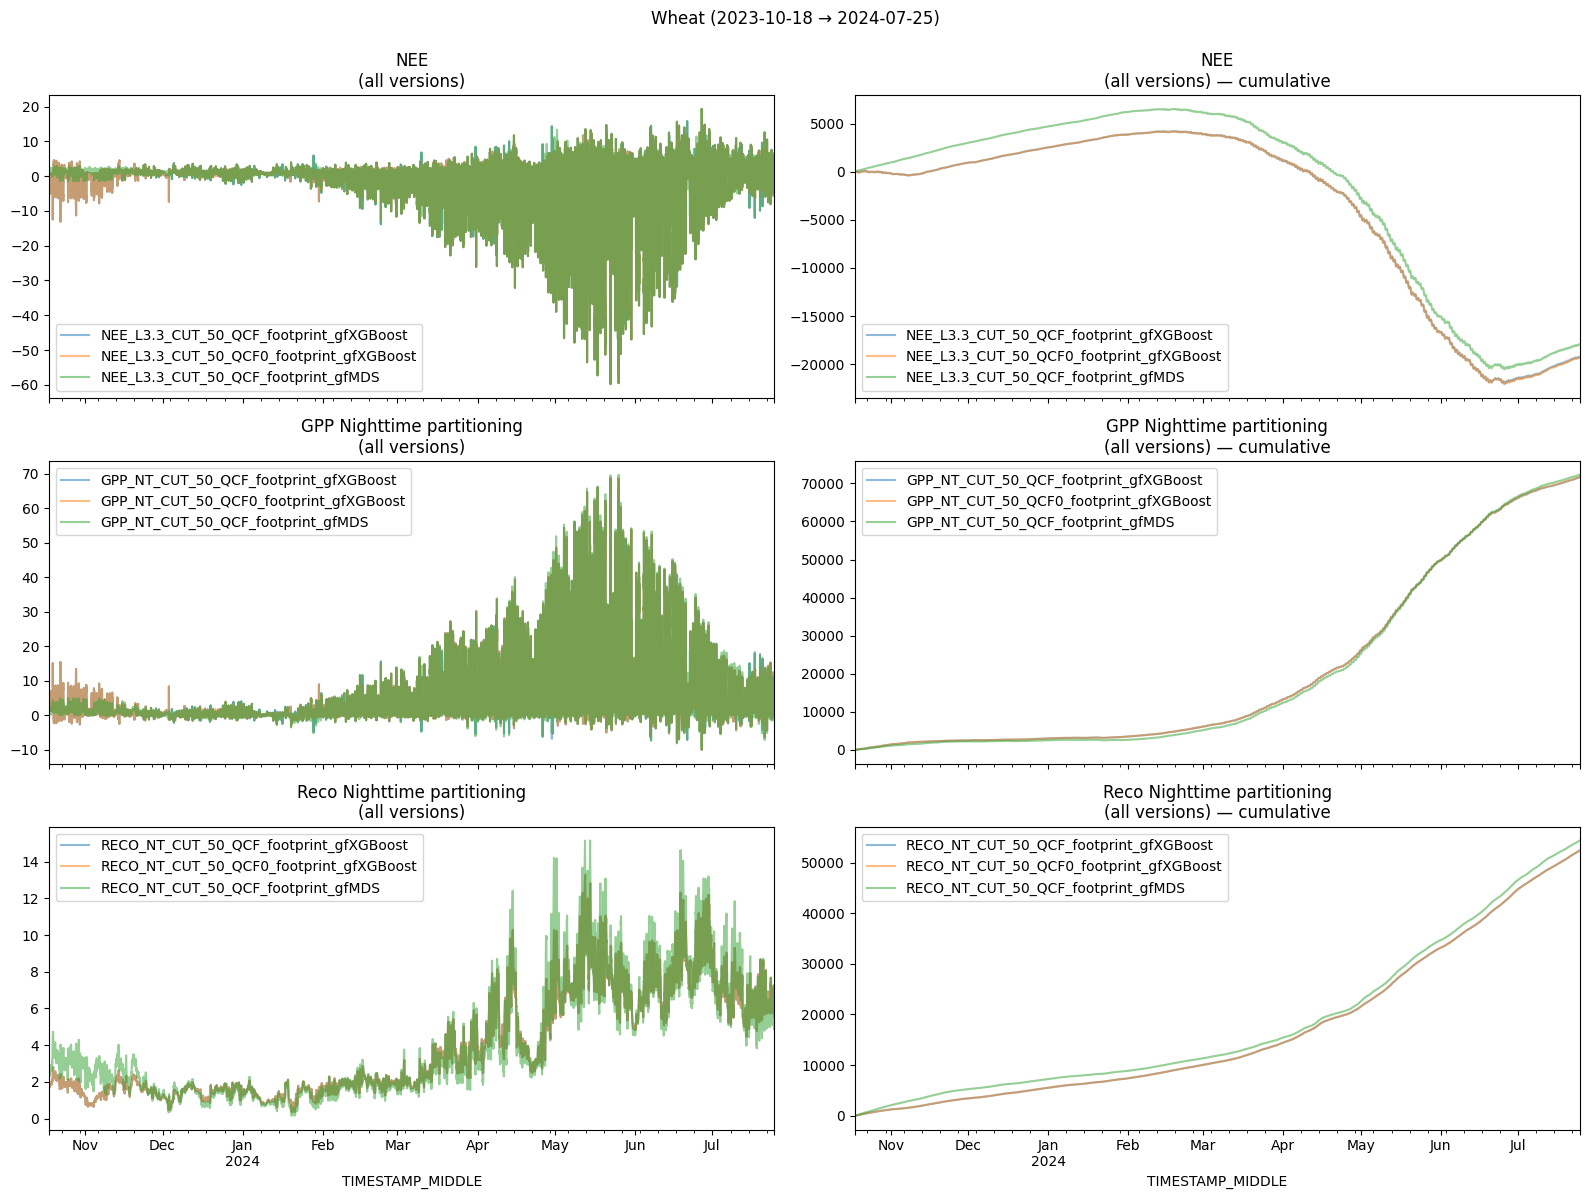

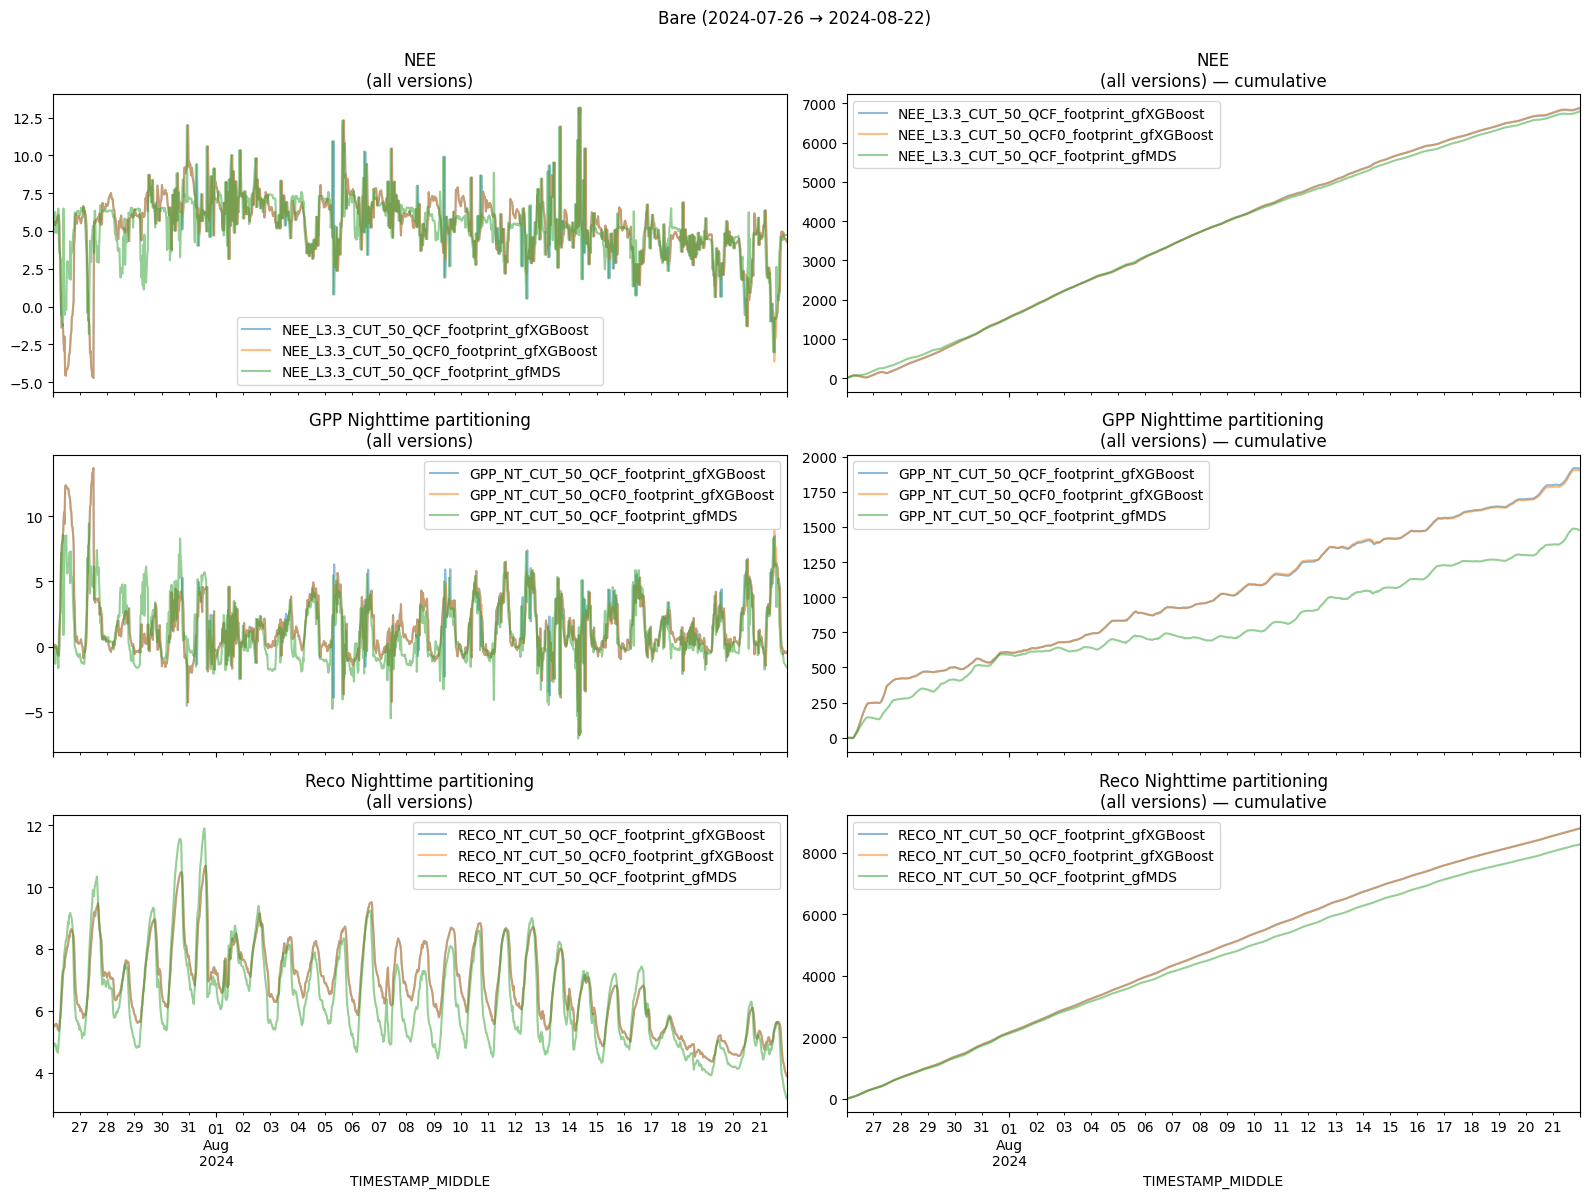

In [9]:
# Define periods
periods = [
    ("2023-10-18", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-08-22", "Bare"),
]

for start, end, label in periods:
    period_df = df.loc[pd.to_datetime(start):pd.to_datetime(end)]
    pairs = [
        ([c for c in df.columns if c.startswith('NEE_L3.3_CUT_50') and (c.endswith('footprint_gfXGBoost') or c.endswith('footprint_gfMDS'))], "NEE\n(all versions)"),       
        ([c for c in df.columns if c.startswith('GPP_NT_CUT_50')], "GPP Nighttime partitioning\n(all versions)"),
        ([c for c in df.columns if c.startswith('RECO_NT_CUT_50')], "Reco Nighttime partitioning\n(all versions)"),
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.5)
        axes[r, 0].set_title(f"{t}")

        # cumulative
        cumulative = period_df[cols].cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.5)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT DATA

In [10]:
filename = "81.6.1_NEE_GF-XGBoost_GPP_RECO"
save_parquet(data=df, filename=filename)

Saved file 81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet (3.477 seconds).


'81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet'

# End of notebook

In [11]:
from datetime import datetime
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-22 16:07:38
